# Audit kvaliteta i oporavak transakcionih podataka: Dirty Cafe Sales

Ovaj projekat je organizovan kao **data quality audit** nad skupom `dirty_cafe_sales.csv`. Fokus je na inventarisanju problema, klasifikaciji defekata i rule-based oporavku podataka uz pomoć domen-specifičnih pravila menija.


## Okvir analize

Notebook je podeljen u pet faza:

1. **Audit sirovog skupa**: šta je formalno prisutno, a šta je stvarno upotrebljivo.
2. **Taksonomija problema**: nedostajuće vrednosti, invalidni tokeni, pogrešni tipovi i parcijalno oštećeni redovi.
3. **Rule engine za oporavak**: popravka uz pomoć cenovnika i aritmetičke konzistentnosti.
4. **Recovery scorecard**: koliko je kvalitativno poboljšanje postignuto posle čišćenja.
5. **Analitički sloj**: EDA nad podacima koji su prošli audit i oporavak.


In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
sns.set_theme(style="ticks")

MENU_PRICES = {
    "Coffee": 2.0,
    "Tea": 1.5,
    "Sandwich": 4.0,
    "Salad": 5.0,
    "Cake": 3.0,
    "Cookie": 1.0,
    "Smoothie": 4.0,
    "Juice": 3.0,
}

INVALID_TOKENS = {"ERROR", "UNKNOWN"}


In [2]:
raw = pd.read_csv("archive/dirty_cafe_sales.csv")
raw.head()


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


## Faza A: Audit sirovog skupa

Prvi korak nije čišćenje, već procena koliko je sirovi skup podataka uopšte spreman za rad. Ovde nas zanima razlika između:

- formalno prisutnih vrednosti,
- vrednosti koje su zapravo validne,
- vrednosti koje izgledaju popunjeno, ali nose signal greške.


In [3]:
audit_overview = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "non_null": raw.notna().sum(),
    "null_pct": (raw.isna().mean() * 100).round(2),
    "unique": raw.nunique(dropna=False)
})
audit_overview


,dtype,non_null,null_pct,unique
Transaction ID,str,10000,0.00,10000
Item,str,9667,3.33,11
Quantity,str,9862,1.38,8
Price Per Unit,str,9821,1.79,9
Total Spent,str,9827,1.73,20
Payment Method,str,7421,25.79,6
Location,str,6735,32.65,5
Transaction Date,str,9841,1.59,368


In [4]:
def normalize_tokens(frame):
    df = frame.copy()
    for col in ["Item", "Quantity", "Price Per Unit", "Total Spent", "Payment Method", "Location", "Transaction Date"]:
        df[col] = df[col].replace(list(INVALID_TOKENS), np.nan)
    return df


def build_typed_view(frame):
    df = frame.copy()
    df["Quantity_num"] = pd.to_numeric(df["Quantity"], errors="coerce")
    df["Price_num"] = pd.to_numeric(df["Price Per Unit"], errors="coerce")
    df["Total_num"] = pd.to_numeric(df["Total Spent"], errors="coerce")
    df["TransactionDate_dt"] = pd.to_datetime(df["Transaction Date"], errors="coerce")
    return df


def quality_scorecard(df):
    rows = {
        "Item": df["Item"].notna().sum(),
        "Quantity": df["Quantity_num"].notna().sum(),
        "Price Per Unit": df["Price_num"].notna().sum(),
        "Total Spent": df["Total_num"].notna().sum(),
        "Payment Method": df["Payment Method"].notna().sum(),
        "Location": df["Location"].notna().sum(),
        "Transaction Date": df["TransactionDate_dt"].notna().sum(),
    }
    out = pd.DataFrame.from_dict(rows, orient="index", columns=["usable_values"])
    out["usable_pct"] = (out["usable_values"] / len(df) * 100).round(2)
    return out


In [5]:
stage_raw = build_typed_view(normalize_tokens(raw))
scorecard_raw = quality_scorecard(stage_raw)
scorecard_raw


,usable_values,usable_pct
Item,9031,90.31
Quantity,9521,95.21
Price Per Unit,9467,94.67
Total Spent,9498,94.98
Payment Method,6822,68.22
Location,6039,60.39
Transaction Date,9540,95.40


Ovaj prikaz je važan jer meri **upotrebljivost**, a ne samo prisustvo. Na primer, kolona može imati malo `NaN` vrednosti, ali i dalje biti lošeg kvaliteta ako sadrži `ERROR` i `UNKNOWN` ili ako ne može da se parsira u odgovarajući tip.


In [6]:
issue_matrix = pd.DataFrame(index=raw.columns)
issue_matrix["missing"] = raw.isna().sum()
issue_matrix["ERROR"] = [(raw[col] == "ERROR").sum() if raw[col].dtype == "object" else 0 for col in raw.columns]
issue_matrix["UNKNOWN"] = [(raw[col] == "UNKNOWN").sum() if raw[col].dtype == "object" else 0 for col in raw.columns]
issue_matrix["issue_total"] = issue_matrix.sum(axis=1)
issue_matrix.sort_values("issue_total", ascending=False)


,missing,ERROR,UNKNOWN,issue_total
Location,3265,0,0,3265
Payment Method,2579,0,0,2579
Item,333,0,0,333
Price Per Unit,179,0,0,179
Total Spent,173,0,0,173
Transaction Date,159,0,0,159
Quantity,138,0,0,138
Transaction ID,0,0,0,0


In [7]:
print("Broj duplikata redova:", raw.duplicated().sum())
print("Broj duplikata Transaction ID:", raw["Transaction ID"].duplicated().sum())

suspicious_preview = raw[
    raw[["Item", "Quantity", "Price Per Unit", "Total Spent", "Payment Method", "Location", "Transaction Date"]]
    .astype(str)
    .apply(lambda s: s.isin(INVALID_TOKENS))
    .any(axis=1)
]
suspicious_preview.head(10)


Broj duplikata redova: 0
Broj duplikata Transaction ID: 0


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
11,TXN_3051279,Sandwich,2,4.0,8.0,Credit Card,Takeaway,ERROR
14,TXN_8915701,ERROR,2,1.5,3.0,NaN,In-store,2023-03-21
18,TXN_8876618,Cake,5,3.0,15.0,Cash,ERROR,2023-03-25
20,TXN_3522028,Smoothie,ERROR,4.0,20.0,Cash,In-store,2023-04-04
25,TXN_7958992,Smoothie,3,4.0,NaN,UNKNOWN,UNKNOWN,2023-12-13
29,TXN_7640952,Cake,4,3.0,12.0,Digital Wallet,Takeaway,ERROR


## Faza B: Taksonomija problema

Sada prelazimo sa prostog brojanja grešaka na klasifikaciju redova. Ideja je da razlikujemo:

- redove sa delimično oštećenim numeričkim poljima,
- redove sa oštećenim kategorijama,
- redove sa problematičnim datumom,
- redove koji imaju dovoljno informacija za sigurnu rekonstrukciju.


In [8]:
typed = stage_raw.copy()
typed["expected_price"] = typed["Item"].map(MENU_PRICES)
typed["expected_total"] = typed["Quantity_num"] * typed["Price_num"]

typed["flag_item_missing"] = typed["Item"].isna()
typed["flag_quantity_missing"] = typed["Quantity_num"].isna()
typed["flag_price_missing"] = typed["Price_num"].isna()
typed["flag_total_missing"] = typed["Total_num"].isna()
typed["flag_payment_missing"] = typed["Payment Method"].isna()
typed["flag_location_missing"] = typed["Location"].isna()
typed["flag_date_missing"] = typed["TransactionDate_dt"].isna()

typed["flag_price_conflict"] = (
    typed["Item"].isin(MENU_PRICES.keys())
    & typed["Price_num"].notna()
    & (typed["Price_num"] != typed["expected_price"])
)

typed["flag_total_conflict"] = (
    typed["Quantity_num"].notna()
    & typed["Price_num"].notna()
    & typed["Total_num"].notna()
    & (~np.isclose(typed["Total_num"], typed["expected_total"]))
)

typed[[c for c in typed.columns if c.startswith("flag_")]].sum().sort_values(ascending=False)


flag_location_missing    3961
flag_payment_missing     3178
flag_item_missing         969
flag_price_missing        533
flag_total_missing        502
flag_quantity_missing     479
flag_date_missing         460
flag_price_conflict         0
flag_total_conflict         0
dtype: int64

In [9]:
issue_summary = pd.Series({
    "Missing location": int(typed["flag_location_missing"].sum()),
    "Missing payment": int(typed["flag_payment_missing"].sum()),
    "Missing item": int(typed["flag_item_missing"].sum()),
    "Missing quantity": int(typed["flag_quantity_missing"].sum()),
    "Missing price": int(typed["flag_price_missing"].sum()),
    "Missing total": int(typed["flag_total_missing"].sum()),
    "Missing date": int(typed["flag_date_missing"].sum()),
    "Price conflicts": int(typed["flag_price_conflict"].sum()),
    "Total conflicts": int(typed["flag_total_conflict"].sum()),
}).sort_values()
issue_summary


Price conflicts        0
Total conflicts        0
Missing date         460
Missing quantity     479
Missing total        502
Missing price        533
Missing item         969
Missing payment     3178
Missing location    3961
dtype: int64

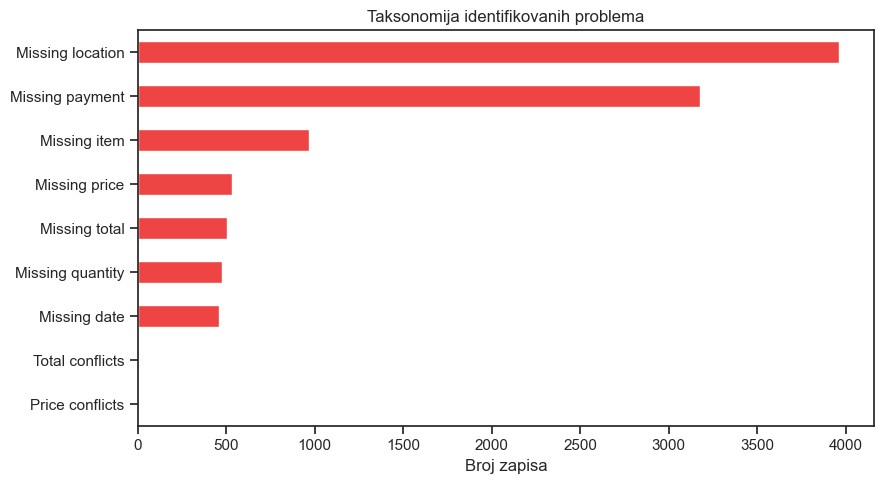

In [10]:
plt.figure(figsize=(9, 5))
issue_summary.plot(kind="barh", color="#ef4444")
plt.title("Taksonomija identifikovanih problema")
plt.xlabel("Broj zapisa")
plt.ylabel("")
plt.tight_layout()
plt.show()


Ključni nalaz ove faze je da dataset nema ozbiljan problem **kontradiktornih transakcija**. Kada su `Item`, `Quantity`, `Price Per Unit` i `Total Spent` istovremeno prisutni, podaci su uglavnom konzistentni. To znači da je veći deo štete u dataset-u posledica **gubitka informacije**, a ne pogrešne informacije.


## Faza C: Rule engine za oporavak podataka

Umesto generičke imputacije, ovde koristimo pravila koja imaju poslovno opravdanje:

- cena može da se vrati iz artikla,
- ukupan račun može da se vrati iz količine i cene,
- količina može da se vrati iz ukupnog računa i cene kada je odnos celobrojan i realističan,
- artikal može da se vrati iz cene samo kada je preslikavanje jednoznačno.


In [11]:
recovered = typed.copy()
repair_log = {}

mask = recovered["Price_num"].isna() & recovered["expected_price"].notna()
repair_log["price_from_item"] = int(mask.sum())
recovered.loc[mask, "Price_num"] = recovered.loc[mask, "expected_price"]

mask = recovered["Total_num"].isna() & recovered["Quantity_num"].notna() & recovered["Price_num"].notna()
repair_log["total_from_quantity_price"] = int(mask.sum())
recovered.loc[mask, "Total_num"] = recovered.loc[mask, "Quantity_num"] * recovered.loc[mask, "Price_num"]

mask = recovered["Quantity_num"].isna() & recovered["Total_num"].notna() & recovered["Price_num"].notna()
ratio = recovered.loc[mask, "Total_num"] / recovered.loc[mask, "Price_num"]
valid_ratio = ratio.isin([1, 2, 3, 4, 5])
repair_log["quantity_from_total_price"] = int(valid_ratio.sum())
recovered.loc[ratio.index[valid_ratio], "Quantity_num"] = ratio[valid_ratio]

price_to_items = {}
for item, price in MENU_PRICES.items():
    price_to_items.setdefault(price, []).append(item)

repair_log["item_from_unique_price"] = 0
mask = recovered["Item"].isna() & recovered["Price_num"].notna()
for price, items in price_to_items.items():
    if len(items) == 1:
        unique_mask = mask & (recovered["Price_num"] == price)
        repair_log["item_from_unique_price"] += int(unique_mask.sum())
        recovered.loc[unique_mask, "Item"] = items[0]

recovered["Payment Method"] = recovered["Payment Method"].fillna("Unknown")
recovered["Location"] = recovered["Location"].fillna("Unknown")
recovered["Month"] = recovered["TransactionDate_dt"].dt.month
recovered["Weekday"] = recovered["TransactionDate_dt"].dt.day_name()
recovered["Weekend"] = recovered["TransactionDate_dt"].dt.dayofweek.isin([5, 6])

repair_log


{'price_from_item': 479,
 'total_from_quantity_price': 479,
 'quantity_from_total_price': 456,
 'item_from_unique_price': 468}

In [12]:
recovery_table = pd.DataFrame.from_dict(repair_log, orient="index", columns=["recovered_rows"])
recovery_table["share_of_dataset_pct"] = (recovery_table["recovered_rows"] / len(recovered) * 100).round(2)
recovery_table.sort_values("recovered_rows", ascending=False)


,recovered_rows,share_of_dataset_pct
price_from_item,479,4.79
total_from_quantity_price,479,4.79
item_from_unique_price,468,4.68
quantity_from_total_price,456,4.56


Ovim pristupom ne "izmišljamo" podatke nasumično, već vraćamo samo ono što može da se opravda jasnim pravilom. Takav pristup čuva semantički integritet skupa i smanjuje rizik od preterane imputacije.


In [13]:
scorecard_recovered = quality_scorecard(recovered)
comparison = scorecard_raw.join(scorecard_recovered, lsuffix="_before", rsuffix="_after")
comparison["gain_values"] = comparison["usable_values_after"] - comparison["usable_values_before"]
comparison["gain_pct_points"] = (comparison["usable_pct_after"] - comparison["usable_pct_before"]).round(2)
comparison


,usable_values_before,usable_pct_before,usable_values_after,usable_pct_after,gain_values,gain_pct_points
Item,9031,90.31,9499,94.99,468,4.68
Quantity,9521,95.21,9977,99.77,456,4.56
Price Per Unit,9467,94.67,9946,99.46,479,4.79
Total Spent,9498,94.98,9977,99.77,479,4.79
Payment Method,6822,68.22,10000,100.00,3178,31.78
Location,6039,60.39,10000,100.00,3961,39.61
Transaction Date,9540,95.40,9540,95.40,0,0.00


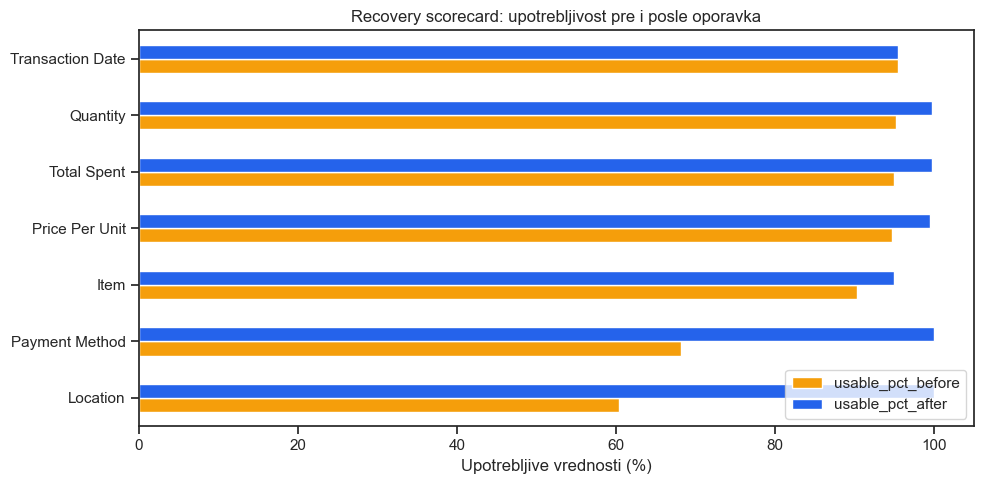

In [14]:
plot_df = comparison[["usable_pct_before", "usable_pct_after"]].sort_values("usable_pct_before")
plot_df.plot(kind="barh", figsize=(10, 5), color=["#f59e0b", "#2563eb"])
plt.title("Recovery scorecard: upotrebljivost pre i posle oporavka")
plt.xlabel("Upotrebljive vrednosti (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()


Najveće formalno poboljšanje vide se kod `Location` i `Payment Method`, ali tu treba biti oprezan: ta poboljšanja uglavnom znače da su praznine standardizovane kao `Unknown`. Kod `Item`, `Quantity`, `Price Per Unit` i `Total Spent` ostvaruje se stvarni **oporavak informacije**, što predstavlja kvalitetnije unapređenje.


## Faza D: Sloj pouzdanosti zapisa

Pošto ni posle oporavka nisu svi redovi jednako kvalitetni, uvodimo jednostavan sistem poverenja po redu. Cilj nije da sve transakcije proglasimo potpuno čistim, već da razlikujemo:

- redove visoke pouzdanosti,
- redove srednje pouzdanosti,
- redove koje i dalje treba tretirati oprezno.


In [15]:
recovered["known_core_fields"] = recovered[["Item", "Quantity_num", "Price_num", "Total_num"]].notna().sum(axis=1)

conditions = [
    (recovered["known_core_fields"] == 4) & recovered["TransactionDate_dt"].notna(),
    (recovered["known_core_fields"] >= 3),
]
choices = ["high", "medium"]
recovered["trust_tier"] = np.select(conditions, choices, default="low")

trust_summary = pd.DataFrame({
    "rows": recovered["trust_tier"].value_counts(),
    "pct": (recovered["trust_tier"].value_counts(normalize=True) * 100).round(2)
})
trust_summary


,rows,pct
trust_tier,,
high,9044,90.44
medium,882,8.82
low,74,0.74


In [16]:
recovered["revenue_known"] = recovered["Total_num"].notna()
coverage_table = pd.DataFrame({
    "count": recovered.groupby("trust_tier")["revenue_known"].size(),
    "revenue_available_pct": (recovered.groupby("trust_tier")["revenue_known"].mean() * 100).round(2)
})
coverage_table


,count,revenue_available_pct
trust_tier,,
high,9044,100.00
low,74,68.92
medium,882,100.00


Ovaj sloj je koristan za dalju analizu i izveštavanje. Na primer, menadžerski KPI izveštaji mogu se graditi samo nad `high` i `medium` segmentima, dok `low` segment ostaje kandidat za dodatnu kontrolu ili isključenje.


## Faza E: EDA nad oporavljenim podacima

Tek nakon audita i rule-based oporavka radimo poslovnu analizu. Time se izbegava da zaključci budu zasnovani na tehnički oštećenim zapisima.


In [17]:
revenue_by_item = (
    recovered.dropna(subset=["Item", "Total_num"])
    .groupby("Item")
    .agg(
        transactions=("Transaction ID", "count"),
        total_revenue=("Total_num", "sum"),
        avg_ticket=("Total_num", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)
revenue_by_item


,transactions,total_revenue,avg_ticket
Item,,,
Salad,1268,19075.0,15.043375
Sandwich,1127,13716.0,12.170364
Smoothie,1094,13344.0,12.197441
Juice,1168,10515.0,9.002568
Cake,1138,10404.0,9.142355
Coffee,1279,7756.0,6.064113
Tea,1198,5433.0,4.535058
Cookie,1207,3585.0,2.970174


In [18]:
channel_mix = pd.crosstab(recovered["Location"], recovered["Payment Method"], normalize="index").round(3)
channel_mix


Payment Method,Cash,Credit Card,Digital Wallet,Unknown
Location,,,,
In-store,0.233,0.226,0.230,0.311
Takeaway,0.220,0.221,0.246,0.313
Unknown,0.225,0.233,0.215,0.327


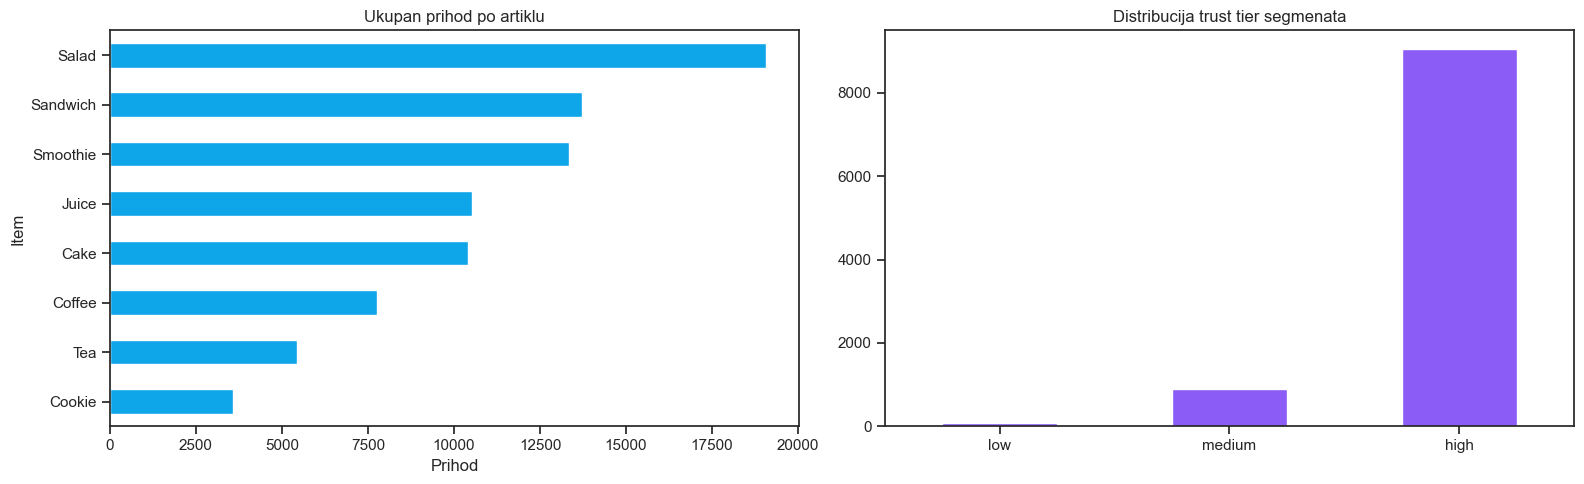

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

revenue_by_item["total_revenue"].sort_values().plot(kind="barh", ax=axes[0], color="#0ea5e9")
axes[0].set_title("Ukupan prihod po artiklu")
axes[0].set_xlabel("Prihod")

trust_summary.loc[["low", "medium", "high"], "rows"].plot(kind="bar", ax=axes[1], color="#8b5cf6")
axes[1].set_title("Distribucija trust tier segmenata")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


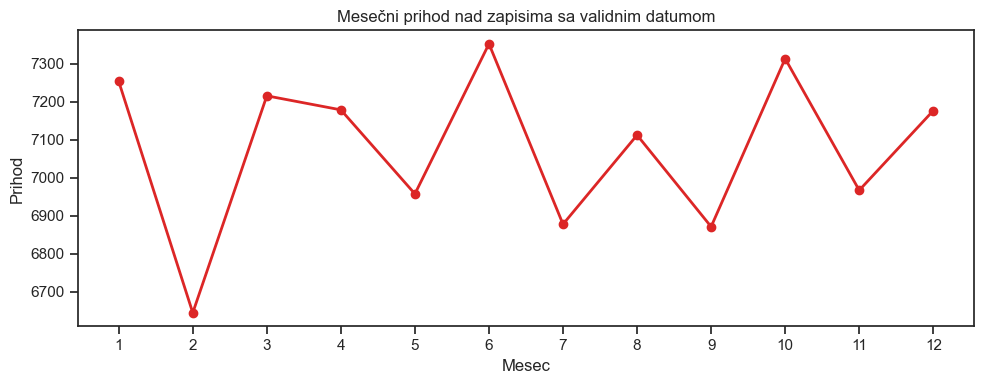

In [20]:
monthly_revenue = (
    recovered.dropna(subset=["Month", "Total_num"])
    .groupby("Month")["Total_num"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(10, 4))
monthly_revenue.plot(marker="o", linewidth=2, color="#dc2626")
plt.title("Mesečni prihod nad zapisima sa validnim datumom")
plt.xlabel("Mesec")
plt.ylabel("Prihod")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()


## Zaključak

U ovom projektu kvalitet podataka nije analiziran kroz klasičan redosled "pregled atributa pa čišćenje", već kroz audit i oporavak. Takav pristup je prikladan za transakcione sisteme u kojima problem često nije logička kontradikcija, već parcijalno oštećen zapis.

Glavni nalazi su sledeći:

- dataset ima mnogo placeholder vrednosti koje formalno izgledaju kao podaci, ali kvare semantiku i tipove,
- cenovnik i aritmetička veza između količine, cene i ukupnog računa omogućavaju značajan rule-based oporavak,
- posle čišćenja se poboljšava upotrebljivost ključnih kolona, posebno numeričkog jezgra transakcije,
- nije svako poboljšanje jednako vredno: zamena praznina sa `Unknown` povećava potpunost, ali ne i informativnost,
- uvođenje `trust_tier` sloja omogućava da se dalja analiza zasniva na nivou pouzdanosti zapisa, a ne samo na sirovoj dostupnosti podataka.

Na taj način dobijamo projekat o kvalitetu podataka koji se oslanja na audit, oporavak i procenu pouzdanosti transakcionih zapisa.
